#COVID-19 Segmentation


Código para cargar, visualizar imagenes con sus máscaras, preprocesar y entrenar a través de una red neuronal con la arquitectura de U-Net.

## Integrantes
- Dongju Mun
- Carlos Manuel Martínez
- Juan Sebastián Chitiva Guerrero
- Evan André Santana Pacheco
- Jorge Manuel Oyoqui Aguilera

Imporamos primero las librerías que vamos a estar trabajando, donde las más relevantes son:
- **cv2:** que se usará epara el tipo de interpólación/borde en la augmentations.
- **time:** para medir cuánto tardan las épocas en el entrenamiento.
- **torch:** el framework principal que será para contruir y entrenar la red neuronal.
- **torch.nn:** para los módulos de la red neuronal.
- **albumentations:** que es la librería de deta augmentation para las imágenes y máscaras.
- **Dataset, DataLoader y WeightedRandomSampler de orch.utils.data:** es para las utilidades de PytTorch para cargar los datos en batches.




Sobre las clases, vamos a tener 4, donde:
- **Ground glass** es una lesión leve y gris tenue que se ve de color amarillo en nuestra figuras.
- **Consolidation** es una lesión severa blanco sólido que se ve de color rojo en nuestras figuras.
- **Lungs** es el tejido pulmonar sano que se ve de color azul en nuestras figuras.
- **Background** es prácticamente todo lo demás, y no poseen color (escala de grises)

In [ ]:
import os
import cv2
import time
import torch
import numpy as np
import pandas as pd
import torch.nn as nn
import albumentations as A
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

# Semilla fija para que los resultados sean reproducibles
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Las 4 clases que podrá tener cada píxel de la máscara
CLASS_NAMES = ["Ground glass", "Consolidation", "Lungs other", "Background"]

Para evitar la carga manual de cada archivo .npy, decidimos guardarlos en un archivo drive, al cual accedemos para pdoer cargarlos directamente desde ahí.

Del drive se cargan las imágenes en formato float32 con sus valores en Hounsfiled Units (HU) y las máscaras en uint8 con sus datos en one-ho

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

# Como los archivos .npy están guardados en drive, los cargamos desde ahí
DATA_DIR = '/content/gdrive/MyDrive/IAconcentrada/covid19/covid-segmentation/'
assert os.path.isfile(DATA_DIR + "images_medseg.npy"), \
    f"No encontré los .npy en {DATA_DIR}\nContenido: {os.listdir(DATA_DIR)}"

images_radiopedia = np.load(DATA_DIR + "images_radiopedia.npy").astype(np.float32)
masks_radiopedia  = np.load(DATA_DIR + "masks_radiopedia.npy").astype(np.uint8)
images_medseg     = np.load(DATA_DIR + "images_medseg.npy").astype(np.float32)
masks_medseg      = np.load(DATA_DIR + "masks_medseg.npy").astype(np.uint8)
test_images       = np.load(DATA_DIR + "test_images_medseg.npy").astype(np.float32)

print("images_radiopedia", images_radiopedia.shape)
print("images_medseg    ", images_medseg.shape)
print("test_images      ", test_images.shape)

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).
images_radiopedia (829, 512, 512, 1)
images_medseg     (100, 512, 512, 1)
test_images       (10, 512, 512, 1)


In [ ]:
"""
Función count_label_conflicts:
Esta función realiza una verificación de integridad en las máscaras para
asegurarse de que cada píxel pertenezca exactamente a una clase
(es decir, que la máscara one-hot sume 1).

ARGS:
Máscara: Array numpy que contiene las máscaras de segmentación.
Name: Nombre para identificar el conjunto de máscaras a analizar


RETURN:
Imprime el número de píxeles que no cumplen con la condición de
pertenecer a una sola clase y el número de slices que contienen
estos píxeles conflictivos.

También imprime la cantidad de píxeles etiquetados como 'Background'
y otra clase.
"""


# Integrity check: each pixel should belong to exactly one class (one-hot mask sums to 1)
def count_label_conflicts(masks, name):
    # Hacemos una suma de clase por píxel, de modo que un píxelo es válido si la suma da 1
    labels_per_pixel = masks.sum(axis=3)
    # Contamos cuántos píxeles tienen una suma diferente a 1
    n_bad = (labels_per_pixel != 1).sum()
    # Contamos en cuántos slices aparece al menos un píxel que sea conflictivo
    n_bad_slices = ((labels_per_pixel != 1).sum(axis=(1, 2)) > 0).sum()
    print(f"{name}: {n_bad} pixels with != 1 label, in {n_bad_slices} slices")
    # Revisamos específicamente como fue el caso de traslape entre las clases
    for c in range(3):
        both = (masks[..., c] == 1) & (masks[..., 3] == 1)
        if both.sum() > 0:
            print(f"    {both.sum()} pixels labeled '{CLASS_NAMES[c]}' AND 'Background'")

# Haxemos la verificación sobre las máscaras originales de las dos fuentes de datos
count_label_conflicts(masks_radiopedia, "radiopedia")
count_label_conflicts(masks_medseg, "medseg")

radiopedia: 22027 pixels with != 1 label, in 273 slices
    7275 pixels labeled 'Ground glass' AND 'Background'
    14752 pixels labeled 'Consolidation' AND 'Background'
medseg: 510 pixels with != 1 label, in 6 slices
    89 pixels labeled 'Ground glass' AND 'Background'
    421 pixels labeled 'Consolidation' AND 'Background'


In [ ]:
"""

Función visualize:
Esta función permite visualizar un lote de imágenes junto con sus
máscaras en caso de requerirlas. Igual al tener una predicción,
se puede visualizar la predicción junto con la máscara real para comparar los resultados.

ARGS:
image_batch: Lote de imágenes a visualizar.
mask_batch: Lote de máscaras correspondientes a las imágenes (opcional).
pred_batch: Lote de predicciones correspondientes a las imágenes (opcional).
En caso de contener pred_ batch: amarillo = TP, rojo = FP, verde = FN.
num_samples: Número de muestras a visualizar (por defecto es 6).



RETURN:
Regresa una visualización del número de imagenes definidas es num_samples,
junto con las máscaras correspondientes y las predicciones si se proporcionan.
"""


def visualize(image_batch, mask_batch=None, pred_batch=None, num_samples=6):
    # From yellowduck/keras-baseline. Row 0: image, rows 1..4: one mask channel per class.
    # If pred_batch is given: yellow = TP, red = FP, green = FN.
    num_classes = mask_batch.shape[-1] if mask_batch is not None else
    num_samples = min(num_samples, len(image_batch))
    # Creamos una cuadrícula donde 1 fila es para la imagen y otra es para cada clase de máscara
    fig, ax = plt.subplots(num_classes + 1, num_samples, figsize=(num_samples * 2, (num_classes + 1) * 2), squeeze=False)
    for i in range(num_samples):
        # En la primera fila la imagen está en escala de grises
        ax[0, i].imshow(image_batch[i, :, :, 0], cmap="gray")
        for j in range(num_classes):
            if pred_batch is None:
                # Si no hay predicción, entonces sólo se muestra la máscara real de esa clase
                ax[j + 1, i].imshow(mask_batch[i, :, :, j], vmin=0, vmax=1)
            else:
                # Si hay predicción, se colorea la comparación píxel a píxel
                # entre la máscara real y la predicha
                true = mask_batch[i, :, :, j] == 1
                pred = pred_batch[i, :, :, j] > 0.5
                rgb = np.zeros(true.shape + (3,))
                rgb[true & pred] = [1, 1, 0] # Colorea de amarillo si acertó la predicción
                rgb[~true & pred] = [1, 0, 0] # Colorea de rojo si predijo de más (falso positivo)
                rgb[true & ~pred] = [0, 1, 0] # Colorea de verde si no detectó (falso negativo)
                ax[j + 1, i].imshow(rgb)
            if i == 0:
                # Etiquetemos únicamente la primera columna para
                # no tener el texto repetido para cada imagen
                ax[j + 1, i].set_ylabel(CLASS_NAMES[j], fontsize=8)
    for a in ax.ravel():
        a.set_xticks([]); a.set_yticks([])
    plt.tight_layout(); plt.show()


"""
Función overlay:
Esta función permite superponer las máscaras de segmentación sobre
las imágenes originales para una mejor visualización.
Se clasifican 3 colores para las clases contenidas en este rango:
amarillo = ground glass, rojo = consolidation, azul = lungs other.

ARGS:
images: Array numpy que contiene las imágenes originales.
masks: Array numpy que contiene las máscaras de segmentación.
indexes: Lista de índices de las imágenes a visualizar.


RETURN:
Se regresa una visualización de las imágenes originales con las
máscaras superpuestas.
"""

def overlay(images, masks, indexes):
    # Lesions painted on top of the slice: yellow = ground glass, red = consolidation, blue = lungs other
    colors = [[1, 0.85, 0], [1, 0.2, 0.2], [0.2, 0.6, 1]]
    fig, ax = plt.subplots(1, len(indexes), figsize=(3 * len(indexes), 3), squeeze=False)
    for a, i in zip(ax[0], indexes):
        img = images[i, :, :, 0]
        # Normalizamos la imagen a [0,1] para poder pintarla en RGB
        gray = (img - img.min()) / (img.max() - img.min())
        rgb = np.stack([gray, gray, gray], axis=2)
        for c in range(3):
            # Para cada clase mezclamos su color sobre los
            # píxeles donde la máscara esté encendida
            m = masks[i, :, :, c] == 1
            rgb[m] = 0.55 * rgb[m] + 0.45 * np.array(colors[c])
        a.imshow(rgb); a.set_title(f"#{i}"); a.axis("off")
    plt.tight_layout(); plt.show()

MedSeg: individual slices with lesions


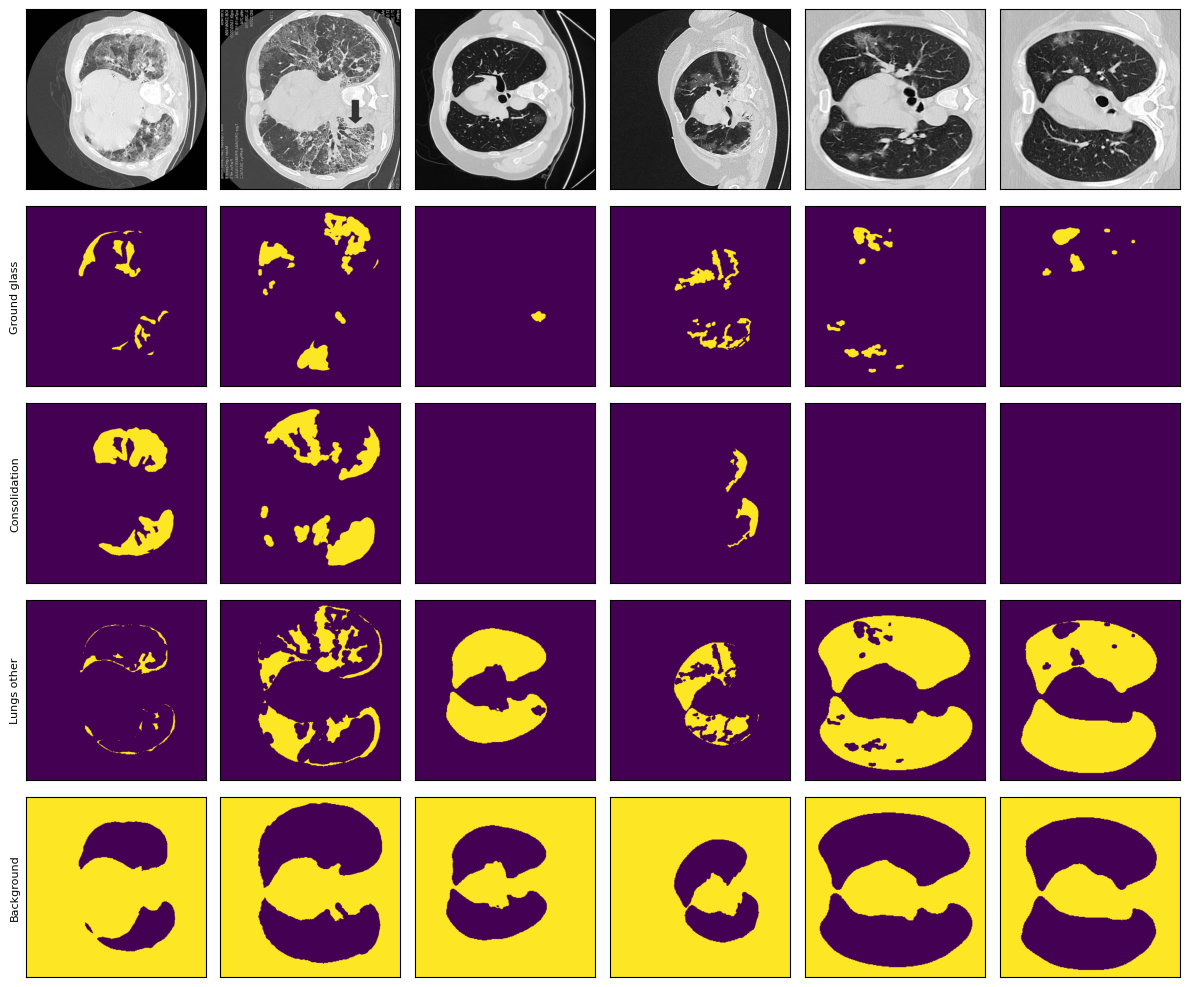

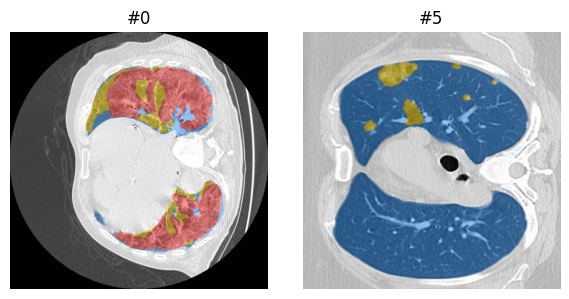

In [ ]:
# Para visualizar algunas imágenes de medseg junto con sus máscaras reales
print("MedSeg: individual slices with lesions")
visualize(images_medseg, masks_medseg, num_samples=6)
overlay(images_medseg, masks_medseg, [0, 5])

**Aclaración:** Las imágenes de test no tienen máscara pues es lo que el modelo estará intentando predecir

Test (MedSeg): slices, no masks


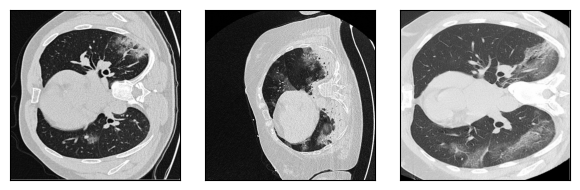

In [ ]:
print("Test (MedSeg): slices, no masks")
visualize(test_images, num_samples=3)

# Data Analysis

## Intensity Distribution (Hounsfield Units)


Para las tomografías computarizadas, se utiliza la escala de Unidades Hounsfield para cuantificar la radiodensidad. Para esta escala, estos son los valores interpretables:

1. Aire abunda en -1000 (Se muestra Negro)
2. Agua destilada es en 0 (aparece gris)
3. Hueso y metal están aproximadamente en 1000 a 3000 (Se muestra blanco)

In [ ]:
# Calculamos las estadísticas básicas de intensidad para cada fuente de imágenes
stats = []
for name, a in [("radiopedia", images_radiopedia), ("medseg", images_medseg), ("test", test_images)]:
    stats.append({"source": name, "mean": a.mean(), "std": a.std(), "min": a.min(),
                  "p1": np.percentile(a, 1), "median": np.median(a), "p99": np.percentile(a, 99), "max": a.max()})
pd.DataFrame(stats).round(1)

,source,mean,std,min,p1,median,p99,max
0,radiopedia,-450.700012,495.500000,-1414.800049,-1334.599976,-248.800003,198.000000,291.000000
1,medseg,-443.200012,494.799988,-1606.500000,-1408.500000,-217.899994,290.200012,597.799988
2,test,-453.100006,507.200012,-1450.000000,-1443.599976,-293.299988,375.000000,875.599976


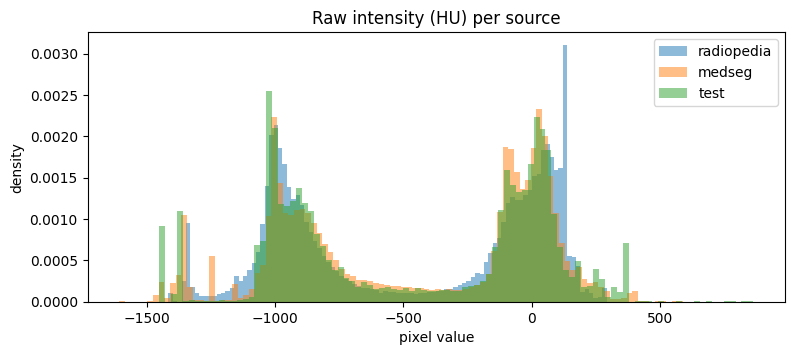

In [ ]:

"""
Función plot_hists:
Esta función permite visualizar histogramas de los valores de píxeles
de diferentes conjuntos de imágenes. Esto es útil para comparar la
distribución de intensidades entre diferentes fuentes de datos.

ARGS:
named_arrays: Lista de tuplas donde cada tupla contiene un nombre y un array de imágenes
title: Título del gráfico (opcional)

RETURN:
Se regresa un gráfico que muestra los histogramas de los valores de píxeles
de los diferentes conjuntos de imágenes.
"""

def plot_hists(named_arrays, title=""):
    plt.figure(figsize=(9, 3.5))
    for name, a in named_arrays:
        # Tomamos 1 de cada 100 píxeles  para poder calcular rápidamente
        # el histograma sin perder la forma de la distribución
        plt.hist(a.ravel()[::100], bins=100, density=True, alpha=0.5, label=name)  # every 100th pixel is plenty
    plt.legend(); plt.title(title); plt.xlabel("pixel value"); plt.ylabel("density"); plt.show()

# COmapramos las distribuciones de intensidad (en HU) de las 3 fuentes de datos
plot_hists([("radiopedia", images_radiopedia), ("medseg", images_medseg), ("test", test_images)],
           title="Raw intensity (HU) per source")

Se observa una concentración para los tres conjuntos de datos una alta concentración de píxeles alrededor de los valores asociados a agua y aire. Esto tiene sentido al analizar imágenes pulmonares, ya que mucha proporción de la imagen corresponde a aire que existe dentro de los pulmones y tejidos que tienen densidades cercanas al agua.

### Imbalance de Clases

,radiopedia,medseg
Ground glass,1.02,4.56
Consolidation,0.23,2.25
Lungs other,14.50,19.99
Background,84.26,73.20


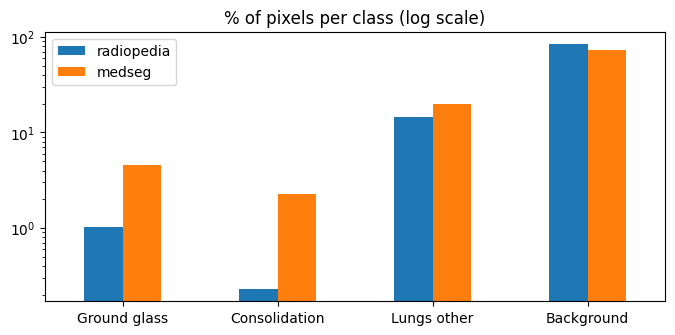

In [ ]:
# Calculamos el porcentaje de píxeles por clase, esto para
# todas las imágenes de cada fuente
frac = pd.DataFrame({
    "radiopedia": masks_radiopedia.mean(axis=(0, 1, 2)) * 100,
    "medseg": masks_medseg.mean(axis=(0, 1, 2)) * 100,
}, index=CLASS_NAMES).round(2)
display(frac)

# Graficamos en escala logarítmica de modo que, como Background
# domina, podamos comparar las clases pequeñas
frac.plot.bar(figsize=(8, 3.5), logy=True, title="% of pixels per class (log scale)")
plt.xticks(rotation=0); plt.show()

Se observa una alta proporción de píxeles en la clase Background. Esto es esperado ya que las regiones de interés ocupan una parte pequeña de cada slice de una Tomografía.

Las clases de mayor interés son Consolidation y Ground Glass, el cual representa la identificación de daño pulmonar que ha sido asociado con COVID-19.

Comparando entre ambos conjuntos de datos, Radiopaedia muestra una menor cantidad de información para la clase Consolidation.

% of slices that contain each class
               radiopedia  medseg
Ground glass         35.8    96.0
Consolidation        28.1    78.0
Lungs other          86.0   100.0
Background          100.0   100.0


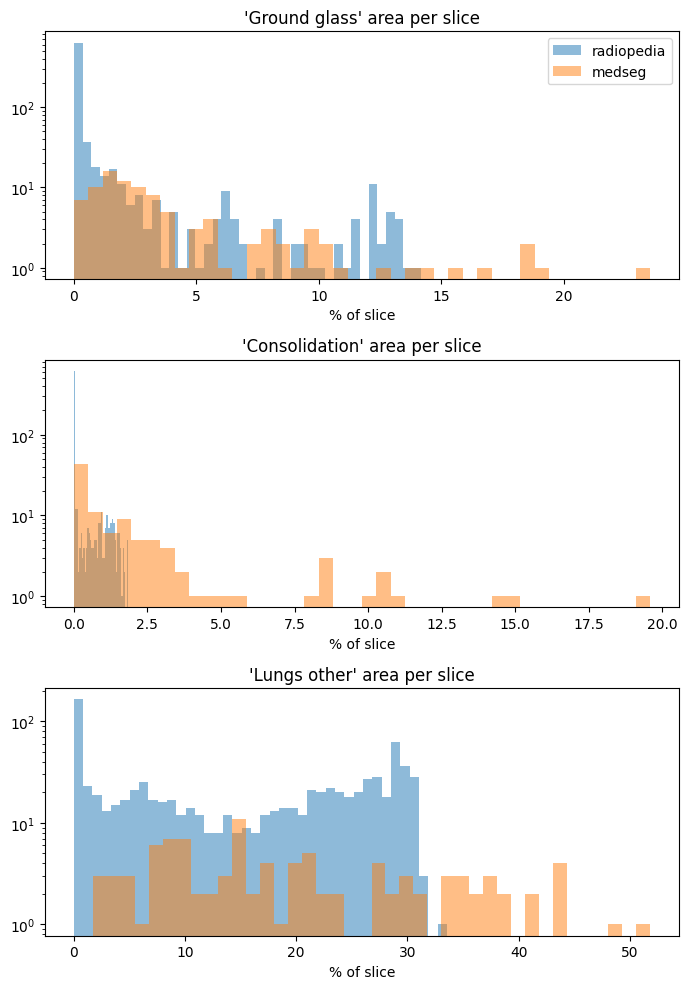

In [ ]:
# Vemos por cada slice qué porcentaje de esa imagen ocupa cada clase
area_radiopedia = masks_radiopedia.mean(axis=(1, 2)) * 100   # (829, 4)
area_medseg     = masks_medseg.mean(axis=(1, 2)) * 100       # (100, 4)

# Vemos en qué pordentaje de slices aparece al menos un píxel de cada clase
print("% of slices that contain each class")
print(pd.DataFrame({"radiopedia": (area_radiopedia > 0).mean(axis=0) * 100,
                    "medseg": (area_medseg > 0).mean(axis=0) * 100}, index=CLASS_NAMES).round(1))

# Generamos un histograma para ver qué tanto ocupa cada clase por slice (esto para las dos fuwentes)
fig, ax = plt.subplots(3, 1, figsize=(7, 10))
for a, c in zip(ax, [0, 1, 2]):
    a.hist(area_radiopedia[:, c], bins=40, alpha=0.5, label="radiopedia")
    a.hist(area_medseg[:, c], bins=40, alpha=0.5, label="medseg")
    a.set_title(f"'{CLASS_NAMES[c]}' area per slice"); a.set_xlabel("% of slice"); a.set_yscale("log")
ax[0].legend(); plt.tight_layout(); plt.show()

## Transform (cleaning and preprocessing)

### Cleaning: Overlapping Labels

Se realiza una limpieza a las máscaras para poder corregir inconsistencias y superposición de un píxel, siendo clasificado en dos clases. Para la máscara one-hot, solo debe pertenecer una clase por píxel. A como se encontró al inicio del reporte en la exploración de datos, se identificaron pixeles con múltiples etiquetas.

Para resolver esto, se conservará la etiqueta y se eliminará la etiqueta de background en estos pixeles superposicionados.

In [ ]:
"""
Función fix_label_conflicts:
Esta función corrige los conflictos de etiquetas en las máscaras de
segmentación identificadas anteriormente. Si un píxel está marcado como
lesión o pulmón y también como fondo, se elimina de la etiqueta de fondo,
manteniendo la etiqueta de lesión o pulmón.

ARGS:
masks: Array numpy que contiene las máscaras de segmentación.

RETURN:
Regresa las máscaras corregidas, asegurando que cada píxel pertenezca
exactamente a una clase (es decir, que la máscara one-hot sume 1).
"""

def fix_label_conflicts(masks):
    # A pixel marked as lesion or lung AND as background: keep the lesion/lung label, clear background
    # Verificamos qué píxeles sí tienen alguna de las 3 clases encendidas (background no cuenta)
    is_lung_or_lesion = masks[..., :3].sum(axis=3) > 0
    # A dichos píxeles les apagamos el canal de background
    # de modo que sólo quede su clase ral
    masks[is_lung_or_lesion, 3] = 0
    # Hacemos nuevamente la verificación para comprobar que ahora cada
    # píxel sume exactamente 1 entre sus 4 canales
    assert (masks.sum(axis=3) == 1).all()
    return masks

# Corregimos las máscaras para las dos fuentes de datos
masks_radiopedia = fix_label_conflicts(masks_radiopedia)
masks_medseg = fix_label_conflicts(masks_medseg)
# Hacemos nuevamente la verificación de conflictos para confirmar que
# ya no queden píxeles problemáticas (con más de 1 clase)
count_label_conflicts(masks_radiopedia, "radiopedia")
count_label_conflicts(masks_medseg, "medseg")

radiopedia: 0 pixels with != 1 label, in 0 slices
medseg: 0 pixels with != 1 label, in 0 slices


## Train / Validation Split

Se realiza la división de los datos en conjuntos de Training y Validation, utilizando el mismo procedimiento establecido en el notebook base. De esta manera, se pueden comparar resultados.

In [ ]:
# Definimos las primeras 24 imágenes de medseg para usarlas como conjunto de validation
# El resto de las imágenes de medseg se dejan para train
val_images = images_medseg[:24]
val_masks  = masks_medseg[:24]
train_images_medseg = images_medseg[24:]
train_masks_medseg  = masks_medseg[24:]
print("val (medseg):", len(val_images), "  train medseg:", len(train_images_medseg), "  radiopedia:", len(images_radiopedia))

val (medseg): 24   train medseg: 76   radiopedia: 829


### Cleaning: Slices without Lung

Se eliminan los slices que no contienen información relevante para la segmentación, los cuales son los que su máscara contiene al 100% Background. Esto ayuda a reducir dato que no aporta información útil al entrenamiento.

Radiopaedia: 829 slices, 116 without lung -> dropped


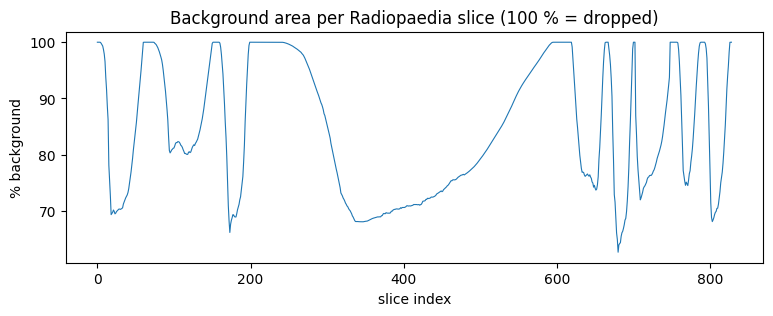

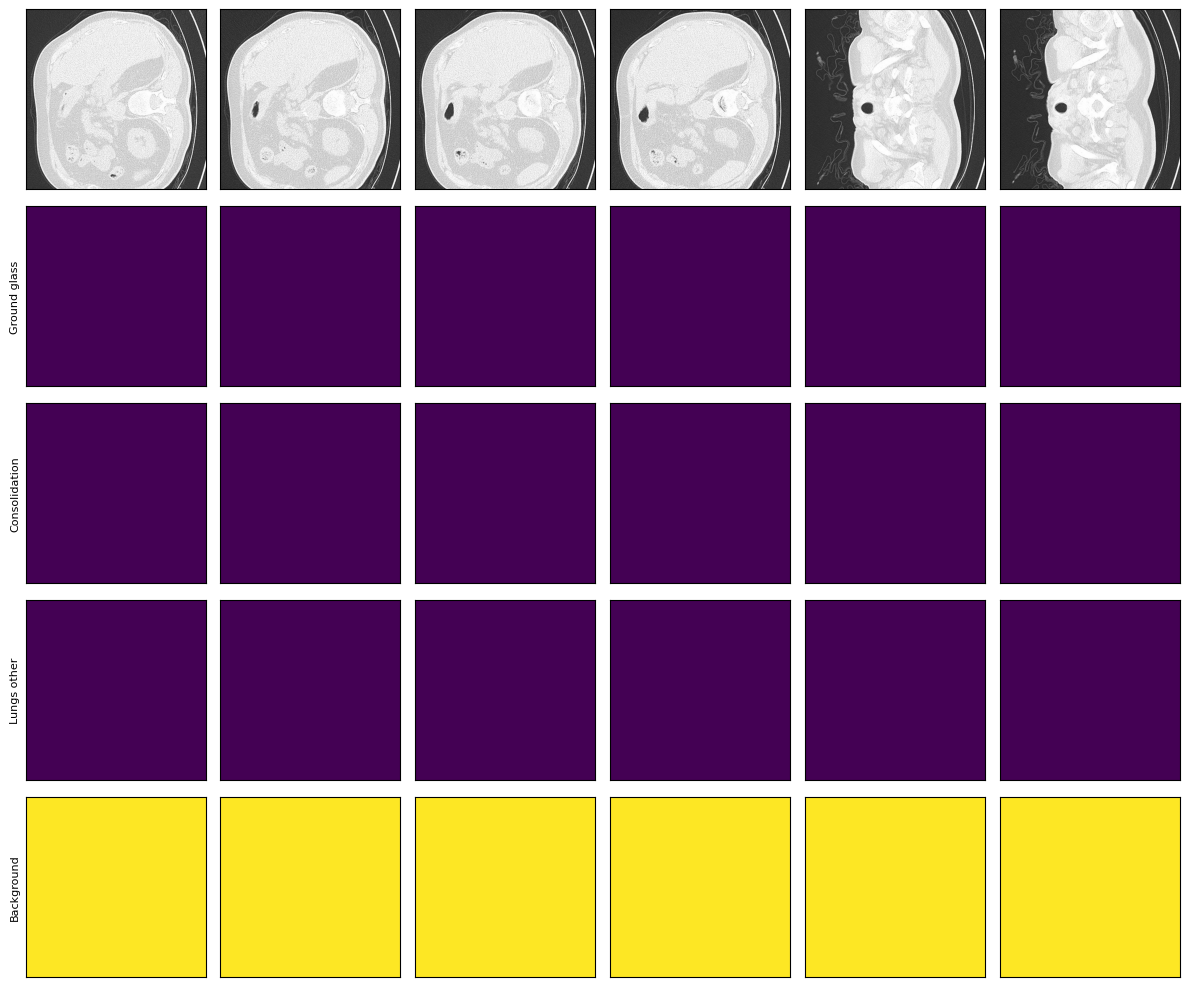

train: (789, 512, 512, 1)  val: (24, 512, 512, 1)  test: (10, 512, 512, 1)


In [ ]:
# Radiopaedia slices that are 100 % background have nothing to segment -> drop them
# Verificamos qué slices de radiopedia sí tuenen algo de pulmón o de lesión
has_lung = masks_radiopedia[..., :3].sum(axis=(1, 2, 3)) > 0
print(f"Radiopaedia: {len(has_lung)} slices, {(~has_lung).sum()} without lung -> dropped")
# Verificamps que los slices a descartar no tengan ningún píxel de lesión
assert masks_radiopedia[~has_lung][..., :2].sum() == 0   # no lesion pixels lost

# Graficamos el porcentaje de background por slice
# Esto se hace para ver qué slices son 100% fondo, que son las que se van a descartar
plt.figure(figsize=(9, 3))
plt.plot(area_radiopedia[:, 3], lw=0.8)
plt.xlabel("slice index"); plt.ylabel("% background"); plt.title("Background area per Radiopaedia slice (100 % = dropped)"); plt.show()

dropped = np.where(~has_lung)[0]
visualize(images_radiopedia[dropped[:6]], masks_radiopedia[dropped[:6]], num_samples=6)

# Creamos  el conjunto final de train
train_images = np.concatenate([train_images_medseg, images_radiopedia[has_lung]])
train_masks  = np.concatenate([train_masks_medseg, masks_radiopedia[has_lung]])
del images_radiopedia, masks_radiopedia, images_medseg, masks_medseg
print("train:", train_images.shape, " val:", val_images.shape, " test:", test_images.shape)

### HU Clipping and Normalization

Se limpian las imágenes al hacer un HU Clipping, el cual consiste en reducir intensidad de valores en la escala Hounsfield dentro de un rango específico. Así se reducen los valores extremos que no sean relevantes para el análisis.

Posteriormente, se normalizan de tal manera que las imágenes compartan la misma escala y puedan ser comparables. Esto es importante debido a la distinta fuente de información (Radiopaedia y Medseg).



rangos -> train [0.00, 1.00] val [0.01, 0.95] test [0.03, 1.00]


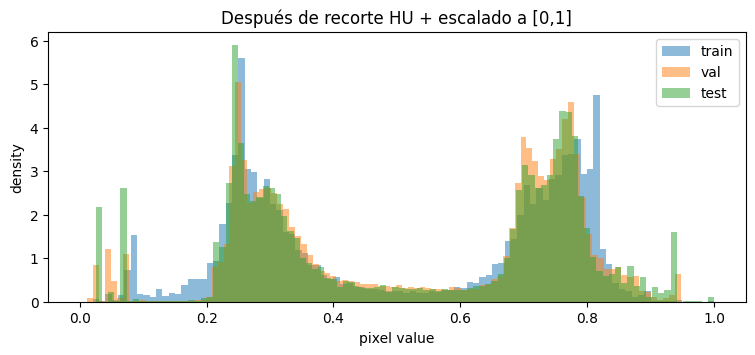

In [ ]:
HU_MIN, HU_MAX = -1500, 500

def normalize_hu(img):
    """Recorta a la ventana HU y escala linealmente a [0,1].
       No usa estadísticas del dataset: la escala Hounsfield es física y ya está calibrada,
       así que train, val y test reciben exactamente la misma transformación."""
    # Con o.clip recortamos cualquier valor que quede fuera del rango [HU_MIN, HU_MAX] a ese límite,
    # de modo que luego de reescale linealmente para que el rango final quede entre 0 y 1
    return ((np.clip(img, HU_MIN, HU_MAX) - HU_MIN) / (HU_MAX - HU_MIN)).astype(np.float32)

# Normalizamos los conjuntos usando sólo las estadísticas de train
train_images = normalize_hu(train_images)
val_images   = normalize_hu(val_images)
test_images  = normalize_hu(test_images)

# Confirmamos que los 3 conjuntos queden en el rango de [0,1]
print("rangos ->",
      f"train [{train_images.min():.2f}, {train_images.max():.2f}]",
      f"val [{val_images.min():.2f}, {val_images.max():.2f}]",
      f"test [{test_images.min():.2f}, {test_images.max():.2f}]")

# Graficamos la distribución de intensidades pero ya normalizada
plot_hists([("train", train_images), ("val", val_images), ("test", test_images)],
           title="Después de recorte HU + escalado a [0,1]")

Revisando la información procesada, se observa que para los 3 conjuntos de datos se mantiene la distribución entre los píxeles -1 y 1.

### Resizing and Data Augmentation

Se revisan las dimensiones en las imagenes junto con sus respectivas máscaras para asegurar que los datos tengan un formato compatible con la entrada del modelo.

También se buscaría aplicar transformaciones de Data Augmentation para así aumenta la variabilidad de los datos utilizados en el entrenamiento. En este caso algunas imagenes, junto con sus máscaras, pueden ser rotadas. Esto se hace con una probabilidad de 90% y un límite de rotación de 90º.


También se aplica transformación que permita ajustar el tamaño de la imagen. Con esto se busca que el modelo sea menos dependiente a la posición, orientación o escala específica de las imagenes, de tal manera que favorece la capacidad de generalizar.

In [ ]:
print("train_images:", train_images.shape)
print("train_masks:", train_masks.shape)
print("val_images:", val_images.shape)
print("val_masks:", val_masks.shape)

train_images: (789, 512, 512, 1)
train_masks: (789, 512, 512, 4)
val_images: (24, 512, 512, 1)
val_masks: (24, 512, 512, 4)


In [ ]:
TARGET_SIZE = 512

# Definimos el pipeline de data augmentation que se aplicará
# únicamente al conjunto de entrenamiento
train_transform = A.Compose([
    # --- geométricas ---
    # Rotaación aleatoria de hasta 20°
    A.Rotate(limit=20, border_mode=cv2.BORDER_REPLICATE,
             mask_interpolation=cv2.INTER_NEAREST, p=0.5),
    # Recorte aleatoria del tamaños variable y luego se reescala con TARGET_SIZE
    A.RandomSizedCrop(min_max_height=(384, 512), size=(TARGET_SIZE, TARGET_SIZE),
                      mask_interpolation=cv2.INTER_NEAREST, p=0.5),
    # Espejo horizontal aleatorio
    A.HorizontalFlip(p=0.5),

    # --- de intensidad (nuevas; requieren datos en [0,1]) ---
    # Pequeños cambios aleatorios en el brillo y el contraste
    A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=0.3),
    # Pequeña variación gamma
    A.RandomGamma(gamma_limit=(80, 120), p=0.3),
])

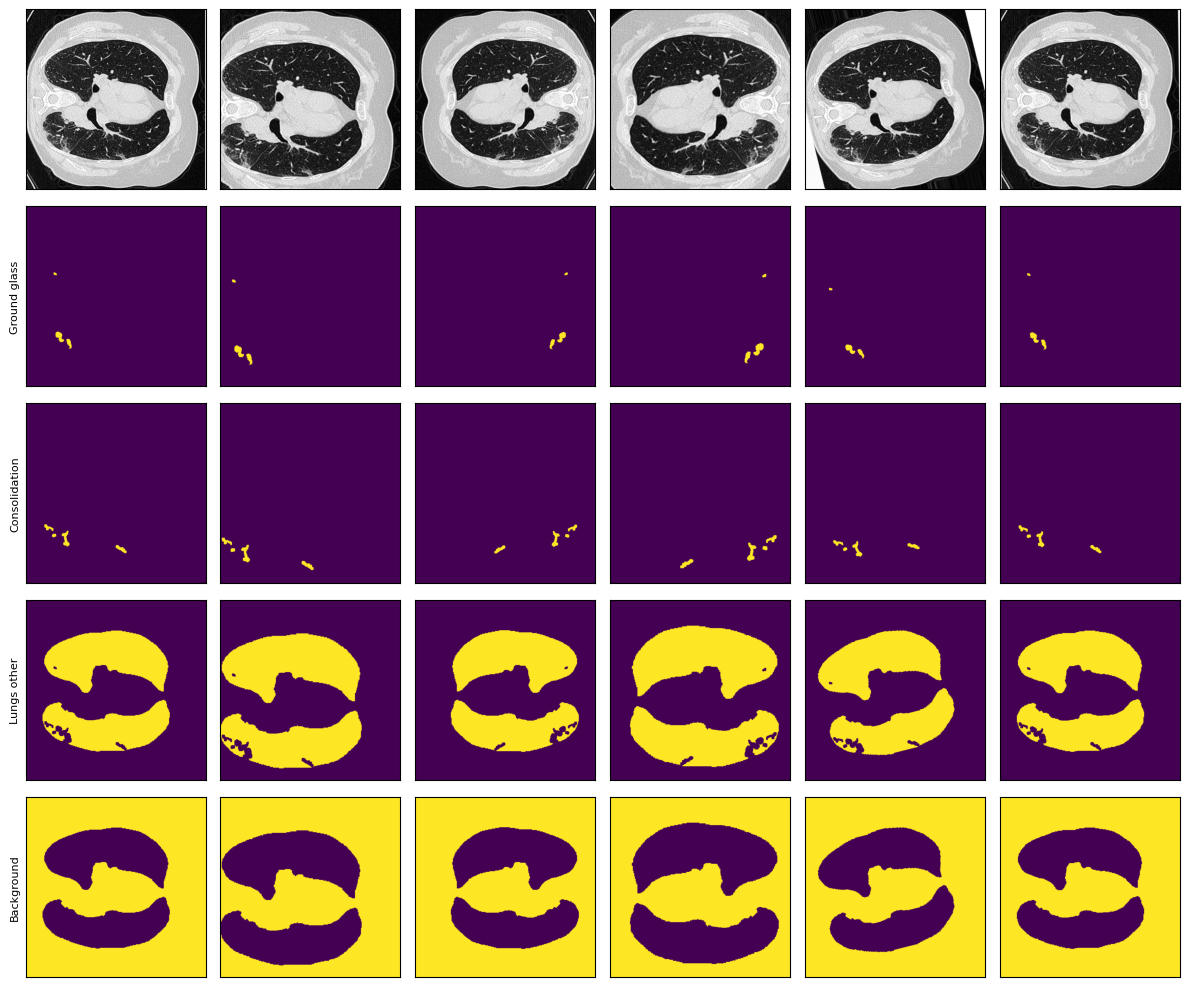

In [ ]:
# Same slice, 6 random augmentations. Nearest-neighbour on the mask keeps it 0/1.
# Tomamos la misma imagen para aplicarle los 6 augmentations previamente definidos
samples = [train_transform(image=train_images[0], mask=train_masks[0]) for _ in range(6)]
aug_images = np.stack([s["image"] for s in samples])
aug_masks  = np.stack([s["mask"] for s in samples])
visualize(aug_images, aug_masks, num_samples=6)
# Verificamos que luego de la augmentation la máscara siga siendo válida
assert (aug_masks.sum(axis=3) == 1).all()

# Inicialización de Modelo


Se inicializan las clases para contruisr el pipeline de entrenamiento utilizando Pytorch.


Para el modelo, se implementa una arquitectura basada en U-Net. El modelo recibe como entrada una imagen CT y genera una predicción pixel a pixel de las distintas clases presentes en la máscara.

Se implementa la clase CovidDataset para facilitar el manejo de imágenes con sus máscaras. Posteriormente, un DataLoader permite organizar las muestras en batches durante el entrenamiento del modelo.



In [ ]:
"""
Clase CovidDataset:
Esta clase hereda de torch.utils.data.Dataset y se utiliza para manejar
el conjunto de datos de imágenes y máscaras de segmentación de COVID-19.


Prepara los datos en un formato adecuado para ser utilizados en un
DataLoader de PyTorch.
"""


class CovidDataset(Dataset):
    def __init__(self, images, masks, transform=None):
        # Guardamos los arrays completos de las imágenes y máscaras
        # junto con el augmentation que se aplicará
        self.images = images
        self.masks = masks
        self.transform = transform

    def __len__(self):
        # Número total de ejemplos disponibles
        return len(self.images)

    def __getitem__(self, idx):
        # Obtenemos una imagen y su máscara
        # correspondiente por índice
        image = self.images[idx]
        mask = self.masks[idx]

        if self.transform is not None:
            # Si hay augmentatio, esta se aplica tanto a la imagen como
            # a la máscara para que ambas tengan la misma
            # tranformación geométrica
            augmented = self.transform(
                image=image,
                mask=mask
            )

            image = augmented["image"]
            mask = augmented["mask"]

        # Convert HWC -> CHW for PyTorch
        image = np.transpose(image, (2, 0, 1))
        mask = np.transpose(mask, (2, 0, 1))

        # Convetimos los tensores de PyTorch en float32
        image = torch.tensor(
            image.copy(),
            dtype=torch.float32
        )

        mask = torch.tensor(
            mask.copy(),
            dtype=torch.float32
        )

        return image, mask

In [ ]:
# Creamos los conjuntos donde train tiene augmentation y validation no (Esto para evaluarlo en limpio)
train_dataset = CovidDataset(train_images, train_masks, transform=train_transform)
val_dataset   = CovidDataset(val_images,   val_masks,   transform=None)

# Oversampling: el train tiene 76 MedSeg y 713 Radiopaedia, pero el TEST es MedSeg.
# En la celda de concatenación, MedSeg va primero, así que son los primeros N.
N_MEDSEG = len(train_images_medseg)
weights  = np.concatenate([np.full(N_MEDSEG, 5.0), np.ones(len(train_dataset) - N_MEDSEG)])
sampler  = WeightedRandomSampler(torch.as_tensor(weights, dtype=torch.double),
                                 num_samples=len(train_dataset), replacement=True)

# El dataset de train usa primero el sampler con pesos ejn lugar de shuffle normal
train_loader = DataLoader(train_dataset, batch_size=16, sampler=sampler,   # sampler reemplaza shuffle
                          num_workers=2, pin_memory=True, persistent_workers=True)
# El dataloader de validation tiene orden fijo, de modo que no ocupa balanceo
val_loader   = DataLoader(val_dataset, batch_size=8, shuffle=False,
                          num_workers=2, pin_memory=True, persistent_workers=True)

print(f"MedSeg pasa de {N_MEDSEG/len(train_dataset):.0%} a "
      f"{weights[:N_MEDSEG].sum()/weights.sum():.0%} de cada época")

MedSeg pasa de 10% a 35% de cada época


In [ ]:
"""
Clase DoubleConv:
Esta clase hereda de nn.Module y representa un bloque de doble
convolución utilizado en redes neuronales convolucionales.
El bloque consiste en dos capas de convolución 2D, cada una seguida
de una normalización por lotes (Batch Normalization) y una función de
activación ReLU. Se utiliza para realizar la arquitectura de U-Net.
"""

# Double Convolution
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.conv = nn.Sequential(
            # 2D convolutional layer with 3 x 3 kernel and padding of 1 (1
            # layer of zeros)
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            # Batch Normalization
            nn.BatchNorm2d(out_channels),
            # ReLU as activation function between layers
            nn.ReLU(inplace=True),

            # the second layer. does the same thing
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
    # Forward pass
    def forward(self, x):
        return self.conv(x)

In [ ]:
# UNet implementation

"""
Clase UNet:
Esta clase hereda de nn.Module y define toda
la arquitectura de red neuronal U-Net.
"""


class UNet(nn.Module):

    def __init__(self):
        super().__init__()

        # Encoder
        # Cada bloque de DoubleConv reduce el tamaño
        # espacial y va aum,entando el número de canales.
        # De esa forma obtenemos características cada vez más abstractas
        self.enc1 = DoubleConv(1, 64)
        self.enc2 = DoubleConv(64, 128)
        self.enc3 = DoubleConv(128, 256)
        self.enc4 = DoubleConv(256, 512)

        # Se reduce a la mitad el ancho y alto
        # en cada nivel del encoder
        self.pool = nn.MaxPool2d(2)

        # Bottleneck
        # El punto más profundo de la red.
        # La imagen es más pequeña pero con más canales
        self.bottleneck = DoubleConv(512, 1024)

        # Decoder
        # Deconvolution
        # ConvTranspose2d agranda el mapa de características
        self.up4 = nn.ConvTranspose2d(
            1024, 512, kernel_size=2, stride=2
        )
        # Luego de agrandar, lo concatemos con su nivel del encoder
        # y de nuevo pasa por un DoubleConv.
        self.dec4 = DoubleConv(1024, 512)

        self.up3 = nn.ConvTranspose2d(
            512, 256, kernel_size=2, stride=2
        )
        self.dec3 = DoubleConv(512, 256)

        self.up2 = nn.ConvTranspose2d(
            256, 128, kernel_size=2, stride=2
        )
        self.dec2 = DoubleConv(256, 128)

        self.up1 = nn.ConvTranspose2d(
            128, 64, kernel_size=2, stride=2
        )
        self.dec1 = DoubleConv(128, 64)

        # 4 output masks
        # Capa final en la que la convolución 1x1
        # convierte los 64 canales en 4
        self.output = nn.Conv2d(64, 4, kernel_size=1)

    def forward(self, x):

        # Encoder va reduciendo el tamaño espacial y
        # aumenta los canales en cada nivel
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))

        # Bottleneck es el nivel más profundo de la red
        b = self.bottleneck(self.pool(e4))

        # Decoder va agrandando el tamño espacial
        # hasta llegar al tamaño original
        d4 = self.up4(b)

        # skipping connection
        # Concatenamos con las características del encoder del mismo nivel
        # para recuperar los detalles espaciales perdidos
        d4 = torch.cat([d4, e4], dim=1)
        d4 = self.dec4(d4)

        d3 = self.up3(d4)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        # Al final, la salida es un mapa de 4 canales del
        # mismo tamaño que la imagen de entrada
        return self.output(d1)

In [ ]:
# Pérdida de entropía cruzada estándar
# Comparamos la clase predicha contra la clase real píxel por píxel
ce = nn.CrossEntropyLoss()

def dice_loss(logits, target_onehot, smooth=1.0):
    """Soft Dice sobre las 3 clases anatómicas (sin background).
       Suma sobre el batch además de sobre H,W: así una clase ausente en una imagen
       se compensa con las imágenes donde sí aparece."""
    # Convertimos los logits en probabilidades y descartamos el canal Background
    probs = torch.softmax(logits.float(), dim=1)[:, :3]
    tgt   = target_onehot[:, :3]
    dims  = (0, 2, 3)
    # Intersección y denominador del coeficiente Dice,
    # donde sumamos sobre todo el batch y toda la imagen
    inter = (probs * tgt).sum(dims)
    denom = probs.sum(dims) + tgt.sum(dims)
    return 1 - ((2 * inter + smooth) / (denom + smooth)).mean()

def combined_loss(logits, target_onehot):
    # Obtenemos el índice por clase que es el que necesita CrossEntropyLoss, no por one-hot
    target_idx = target_onehot.argmax(dim=1)          # one-hot (B,4,H,W) -> índices (B,H,W)
    # La pérdida final combina la entropía cruzada con Dice
    # Entropía cruzada es para clasificar bien en general
    # Dice es para clases pequeñas o desbalanceadas
    return ce(logits.float(), target_idx) + dice_loss(logits, target_onehot)

@torch.no_grad()
def predict_probs(model, x, tta=False):
    """Probabilidades softmax. Con TTA promedia la predicción del espejo horizontal.
       Se promedian PROBABILIDADES, no máscaras binarias: binarizar antes pierde la confianza."""
    p = torch.softmax(model(x).float(), dim=1)
    if tta:
        p_flip = torch.softmax(model(torch.flip(x, dims=[3])).float(), dim=1)
        p = 0.5 * (p + torch.flip(p_flip, dims=[3]))
    return p

@torch.no_grad() # No ocupamos los gradientes al predecir
def evaluate(model, loader, device, tta=False):
    """Dice acumulado sobre TODO el val, no promedio de Dices por batch."""
    model.eval() # Desactivamos dropuut/batchnorm en modo entrenamiento
    inter = torch.zeros(4, device=device)
    denom = torch.zeros(4, device=device)
    losses = []
    for images, masks in loader:
        images, masks = images.to(device), masks.to(device)
        # Guardamos ka pérdida del batch
        losses.append(combined_loss(model(images), masks).item())
        # Tomamos la clase más probable por píxel para calular el Dice
        pred = predict_probs(model, images, tta).argmax(dim=1)
        true = masks.argmax(dim=1)
        # Acumulamos intersección y denominador de cada clase a lo
        # largo del conjutno de validation
        for c in range(4):
            p, t = (pred == c), (true == c)
            inter[c] += (p & t).sum()
            denom[c] += p.sum() + t.sum()
    # Si una clase no aparece nunca, le asignamos Dice=1 para no dividir entre cero
    dice = torch.where(denom > 0, 2 * inter / denom, torch.ones_like(denom))
    return dice.cpu().numpy(), float(np.mean(losses))

In [ ]:
# check which device to use gpu or cpu
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = UNet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

**Aclaración:** En el siguiente bloque volvemos a definir device, model y optimizer ya que esta es la configuración que usamos realmente para entrenar (esto debido a que la anterior tomaba demasiado tiempo y tuvimos que optimizar para poder conseguir resultados)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = UNet().to(device)

EPOCHS = 30
# El learning rate baja de poco a poco siguiendo la curva de coseno a lo largo de las épocas
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

print(f"parámetros: {sum(p.numel() for p in model.parameters())/1e6:.1f} M | device: {device}")

parámetros: 31.0 M | device: cuda


In [ ]:
from torch.amp import autocast, GradScaler # el import actualizado, sin warnings
from tqdm import tqdm # barra de progreso durante el entrenamiento

# Grandscaler ayuda a evitar problemas numéricos al usar precisión mixta
# (es decir, cuando trabajamos con float16 y float32 a la vez)
scaler = GradScaler("cuda")
best_score = -1.0
history = {"train_loss": [], "val_loss": [], "dice": []}

# Ciclo principal del entrenamiento
for epoch in range(EPOCHS):
    t0 = time.time() # Medimos cuánto tarda la época
    lr_now = optimizer.param_groups[0]["lr"]

    # EN el modo de entrenamiento activamos dropout/batchnorm
    # en su modo de aprendizaje
    model.train()
    running_loss = 0.0
    # Recorremos el Dataloader de train batch por batch
    for images, masks in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}", leave=False):
        images = images.to(device, non_blocking=True)
        masks  = masks.to(device, non_blocking=True)
        optimizer.zero_grad() # Limpiamos loa gradientes anteriores
        # Usamos autocast para precisión mixta y así acelerar el entrenamiento
        with autocast("cuda"):
            loss = combined_loss(model(images), masks)
        # Scaler ajusta ña escala de la pérdida  para que
        # backward funcione bien con float16
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        running_loss += loss.item()
    train_loss = running_loss / len(train_loader) # Pérdida promedio de la épcoa en train

    # Al final de cada época se evalúa en el conjunto de validation
    dice, val_loss = evaluate(model, val_loader, device, tta=False)
    scheduler.step() # Actualizamos el learning rate según el scheduler de coseno
    score = (dice[0] + dice[1]) / 2        # solo las lesiones: es lo que te evalúan

    # Guardamos el historial de métricas para graficarlas después
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["dice"].append(dice)

    flag = ""
    # Si el score de esta época es el mejor hasta ahora,
    # entonces guardamos una copia del modelo
    if score > best_score:
        best_score, flag = score, "  <-- mejor"
        torch.save(model.state_dict(), "best.pt")

    print(f"Epoch {epoch+1:2d}/{EPOCHS} | {time.time()-t0:5.0f}s | lr {lr_now:.2e} | "
          f"train {train_loss:.4f} | val {val_loss:.4f}")
    print(f"   GG {dice[0]:.4f} | Cons {dice[1]:.4f} | Lungs {dice[2]:.4f} | "
          f"Bg {dice[3]:.4f} | lesiones {score:.4f}{flag}")

print(f"\nMejor Dice de lesiones: {best_score:.4f}  ->  best.pt")

Epoch  1/30 |    91s | lr 3.00e-04 | train 1.4509 | val 1.4535
   GG 0.4506 | Cons 0.0000 | Lungs 0.6937 | Bg 0.8879 | lesiones 0.2253  <-- mejor


Epoch  2/30 |   109s | lr 2.99e-04 | train 1.0730 | val 0.9887
   GG 0.6007 | Cons 0.0000 | Lungs 0.8793 | Bg 0.9783 | lesiones 0.3004  <-- mejor


Epoch  3/30 |   109s | lr 2.97e-04 | train 0.9085 | val 0.9267
   GG 0.5836 | Cons 0.0810 | Lungs 0.8720 | Bg 0.9807 | lesiones 0.3323  <-- mejor


Epoch  4/30 |   109s | lr 2.93e-04 | train 0.8233 | val 0.9288
   GG 0.3810 | Cons 0.2674 | Lungs 0.8357 | Bg 0.9726 | lesiones 0.3242


Epoch  5/30 |   109s | lr 2.87e-04 | train 0.6983 | val 0.7263
   GG 0.5954 | Cons 0.3087 | Lungs 0.8977 | Bg 0.9842 | lesiones 0.4520  <-- mejor


...

Epoch 26/30 |   110s | lr 2.01e-05 | train 0.3420 | val 0.6153
   GG 0.6472 | Cons 0.3405 | Lungs 0.9152 | Bg 0.9898 | lesiones 0.4938


Epoch 27/30 |   109s | lr 1.30e-05 | train 0.3271 | val 0.5818
   GG 0.6644 | Cons 0.4106 | Lungs 0.9157 | Bg 0.9896 | lesiones 0.5375


Epoch 28/30 |   109s | lr 7.34e-06 | train 0.3214 | val 0.5760
   GG 0.6753 | Cons 0.4112 | Lungs 0.9176 | Bg 0.9898 | lesiones 0.5432


Epoch 29/30 |   109s | lr 3.28e-06 | train 0.3291 | val 0.5977
   GG 0.6641 | Cons 0.3789 | Lungs 0.9151 | Bg 0.9891 | lesiones 0.5215


Epoch 30/30 |   109s | lr 8.22e-07 | train 0.3407 | val 0.5846
   GG 0.6675 | Cons 0.4045 | Lungs 0.9157 | Bg 0.9892 | lesiones 0.5360

Mejor Dice de lesiones: 0.5469  ->  best.pt


               sin TTA  con TTA       Δ
Ground glass    0.5850   0.5910  0.0059
Consolidation   0.5088   0.5053 -0.0035
Lungs other     0.9136   0.9155  0.0019
Background      0.9890   0.9893  0.0003
TTA en test: True


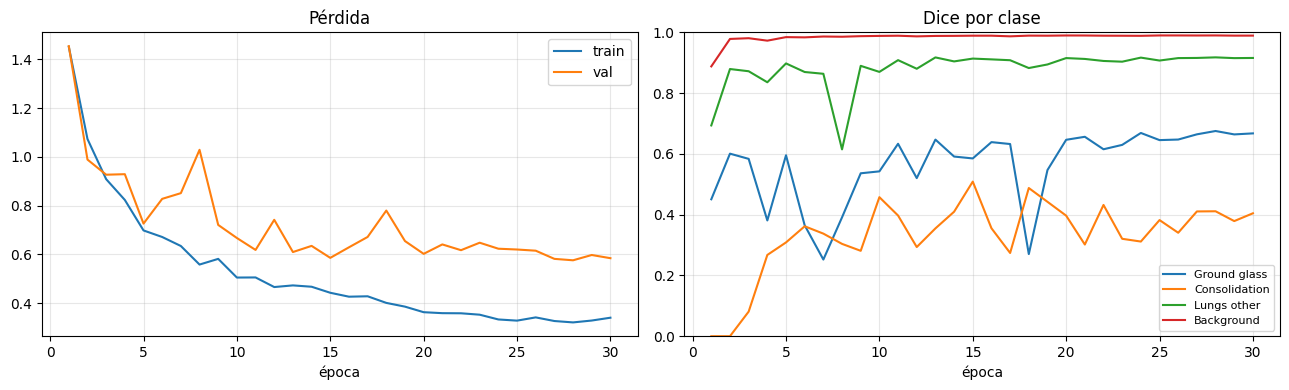

In [ ]:
# Recuperamos  el mejor modelo guardado durante el entrenamiento
model.load_state_dict(torch.load("best.pt"))

# COmparamos el desempeño con y sin Test-Time Augmentation (TTA)
# para ver si conviene usarlo para el conjunto de test
d_sin, _ = evaluate(model, val_loader, device, tta=False)
d_con, _ = evaluate(model, val_loader, device, tta=True)
print(pd.DataFrame({"sin TTA": d_sin, "con TTA": d_con, "Δ": d_con - d_sin},
                   index=CLASS_NAMES).round(4))
# Usamos TTA en test sólo si mjeora el Dice de las clases de lesión
USE_TTA = (d_con[0] + d_con[1]) >= (d_sin[0] + d_sin[1])
print("TTA en test:", USE_TTA)

# Gráfica de la evolución de la pérdida y del Dice por clase a lo largo de las épocas
ep = np.arange(1, len(history["train_loss"]) + 1)
dpc = np.array(history["dice"])
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(ep, history["train_loss"], label="train"); ax[0].plot(ep, history["val_loss"], label="val")
ax[0].set_title("Pérdida"); ax[0].set_xlabel("época"); ax[0].legend(); ax[0].grid(alpha=0.3)
for c, n in enumerate(CLASS_NAMES): ax[1].plot(ep, dpc[:, c], label=n)
ax[1].set_title("Dice por clase"); ax[1].set_xlabel("época"); ax[1].set_ylim(0, 1)
ax[1].legend(fontsize=8); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

guardado: (10, 512, 512, 4)


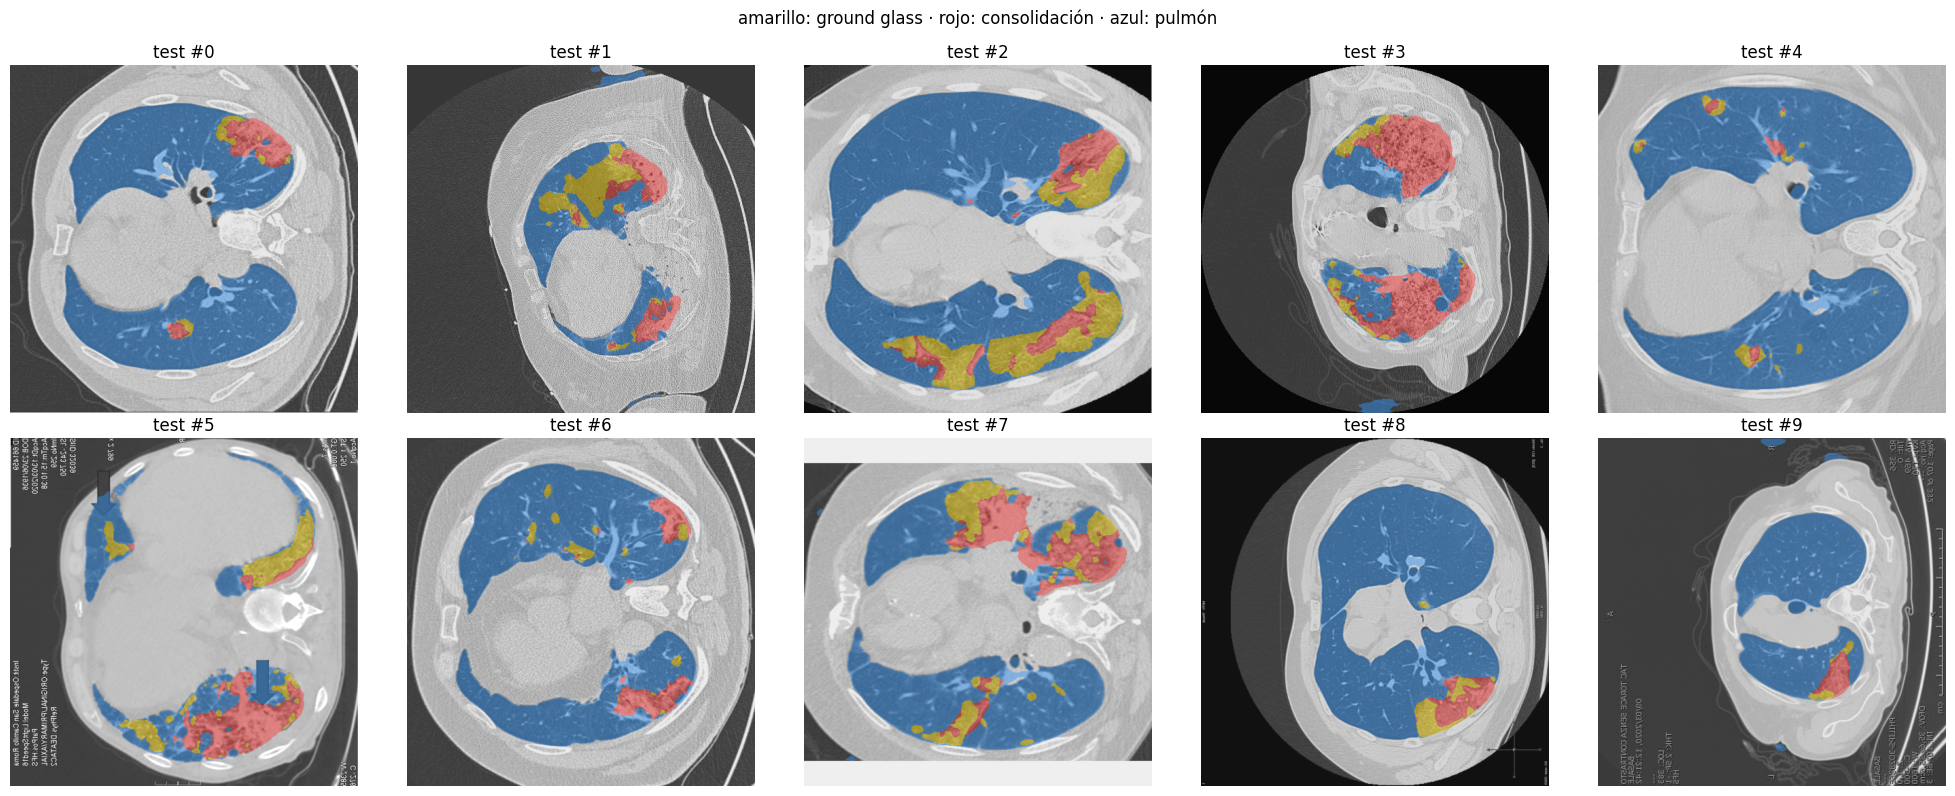

In [ ]:
model.eval() # modo de evaluación
# Convertimos las imágenes de test a tensor y al formato CHW que espera PyTorch
test_X = torch.from_numpy(test_images.transpose(0, 3, 1, 2)).float()

preds = []
# Predecimos 2 imágenes a la vez para no saturar la GPU
for i in range(0, len(test_X), 2):                      # de a 2 para no llenar la VRAM
    p = predict_probs(model, test_X[i:i+2].to(device), tta=USE_TTA)
    # Tomamos la clase más probable por píxel en vez de tener un umbral fijo
    preds.append(p.argmax(dim=1).cpu().numpy().astype(np.uint8))   # argmax, no umbral 0.5
test_pred = np.concatenate(preds)                        # (10, 512, 512)

# Convertimos la predicción de índices de clase de nuevo al formato one-hot,
# de modo que sea igual al formato original de las máscaras
test_onehot = np.eye(4, dtype=np.uint8)[test_pred]       # (10, 512, 512, 4), formato original
np.save("test_prediction.npy", test_onehot)
print("guardado:", test_onehot.shape)

# Las predicciones finales de las imágenes de test se ven coloreadas por clase
colors = np.array([[1, 0.85, 0], [1, 0.2, 0.2], [0.2, 0.6, 1]])
fig, ax = plt.subplots(2, 5, figsize=(20, 8))
for i, a in enumerate(ax.ravel()):
    g = test_images[i, :, :, 0]
    rgb = np.stack([g, g, g], axis=-1)
    for c in range(3):
        m = test_pred[i] == c
        rgb[m] = 0.55 * rgb[m] + 0.45 * colors[c]
    a.imshow(rgb); a.set_title(f"test #{i}"); a.axis("off")
plt.suptitle("amarillo: ground glass · rojo: consolidación · azul: pulmón", y=0.99)
plt.tight_layout(); plt.show()

In [ ]:
# Kaggle submission

# the first two lesion classes
test_masks_prediction = test_onehot[..., :2]

print("Kaggle prediction shape:", test_masks_prediction.shape)

assert test_masks_prediction.shape == (10, 512, 512, 2)

flat_predictions = test_masks_prediction.ravel().astype(int)

submission = pd.DataFrame({
    "Id": np.arange(len(flat_predictions)),
    "Predicted": flat_predictions
})

submission.to_csv(
    "submission.csv",
    index=False
)

print("Shape:", submission.shape)
print(submission.head(10))